In [1]:
print("Customer Feedback NMF Project Started!")

Customer Feedback NMF Project Started!


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Reviews_3000.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

ModuleNotFoundError: No module named 'pandas'

In [3]:
import sys
print(sys.executable)



c:\Users\Dell-03\AppData\Local\Programs\Python\Python310\python.exe


In [4]:
%pip install pandas numpy


^C
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Dell-03\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Reviews_3000.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (3000, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [2]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Column Names:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      3000 non-null   int64 
 1   ProductId               3000 non-null   object
 2   UserId                  3000 non-null   object
 3   ProfileName             3000 non-null   object
 4   HelpfulnessNumerator    3000 non-null   int64 
 5   HelpfulnessDenominator  3000 non-null   int64 
 6   Score                   3000 non-null   int64 
 7   Time                    3000 non-null   int64 
 8   Summary                 3000 non-null   object
 9   Text                    3000 non-null   object
dtypes: int64(5), object(5)
memory usage: 234.5+ KB

Missing Values:
Id                        0
Produ

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x="Score", data=df)

plt.title("Customer Review Score Distribution")
plt.xlabel("Rating Score")
plt.ylabel("Number of Reviews")
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [4]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Dell-03\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


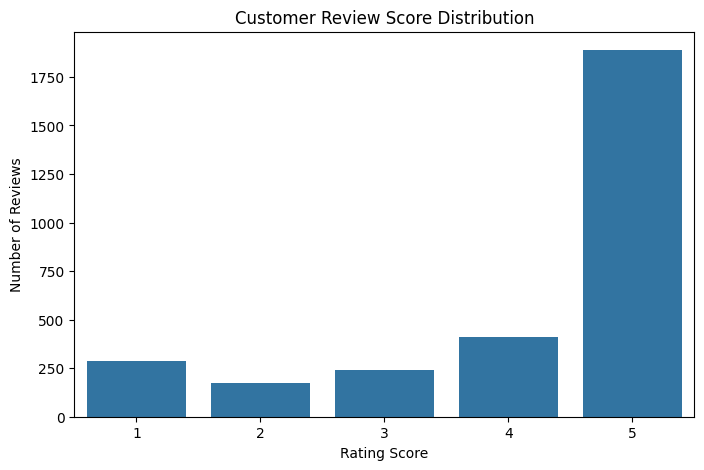

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x="Score", data=df)

plt.title("Customer Review Score Distribution")
plt.xlabel("Rating Score")
plt.ylabel("Number of Reviews")

plt.show()

In [6]:
def get_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(get_sentiment)

print(df[["Score", "Sentiment"]].head(10))

   Score Sentiment
0      5  Positive
1      1  Negative
2      4  Positive
3      2  Negative
4      5  Positive
5      4  Positive
6      5  Positive
7      5  Positive
8      5  Positive
9      5  Positive


In [7]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    2297
Negative     461
Neutral      242
Name: count, dtype: int64


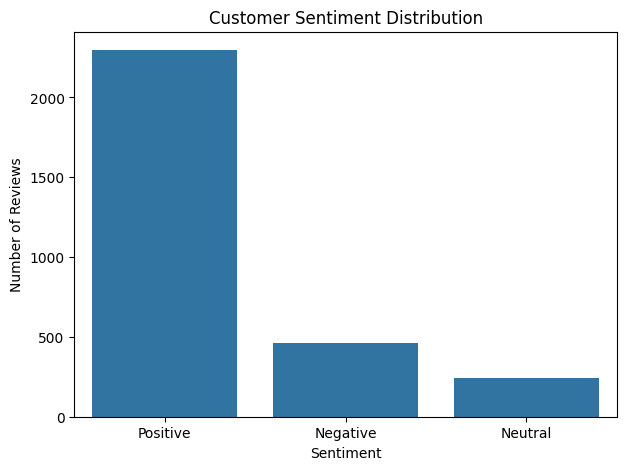

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(x="Sentiment", data=df)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [9]:
df["Review_Length"] = df["Text"].astype(str).apply(len)

print(df["Review_Length"].describe())

count    3000.000000
mean      411.293333
std       419.786816
min        57.000000
25%       176.000000
50%       288.000000
75%       489.000000
max      5276.000000
Name: Review_Length, dtype: float64


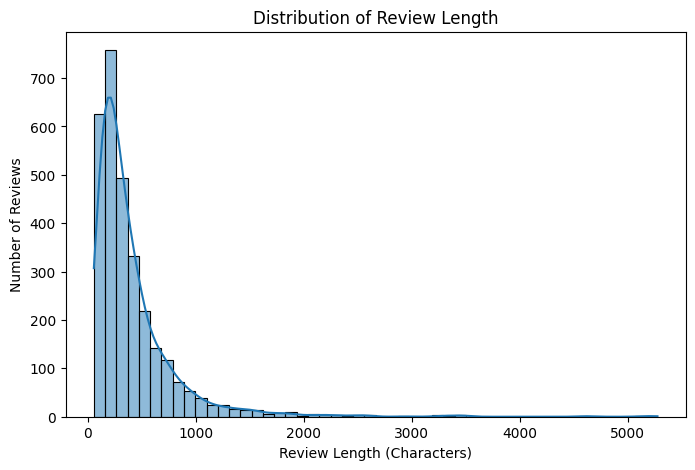

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Review_Length"], bins=50, kde=True)

plt.title("Distribution of Review Length")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Number of Reviews")

plt.show()

In [12]:
df["Date"] = pd.to_datetime(df["Time"], unit="s")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.to_period("M").astype(str)

print(df[["Time", "Date", "Year", "Month"]].head())

         Time       Date  Year    Month
0  1303862400 2011-04-27  2011  2011-04
1  1346976000 2012-09-07  2012  2012-09
2  1219017600 2008-08-18  2008  2008-08
3  1307923200 2011-06-13  2011  2011-06
4  1350777600 2012-10-21  2012  2012-10


In [13]:
print("Year Range:", df["Year"].min(), "to", df["Year"].max())
print("\nReviews by Year:")
print(df["Year"].value_counts().sort_index())

Year Range: 2000 to 2012

Reviews by Year:
Year
2000      2
2004      4
2005      9
2006     50
2007    146
2008    209
2009    316
2010    565
2011    802
2012    897
Name: count, dtype: int64


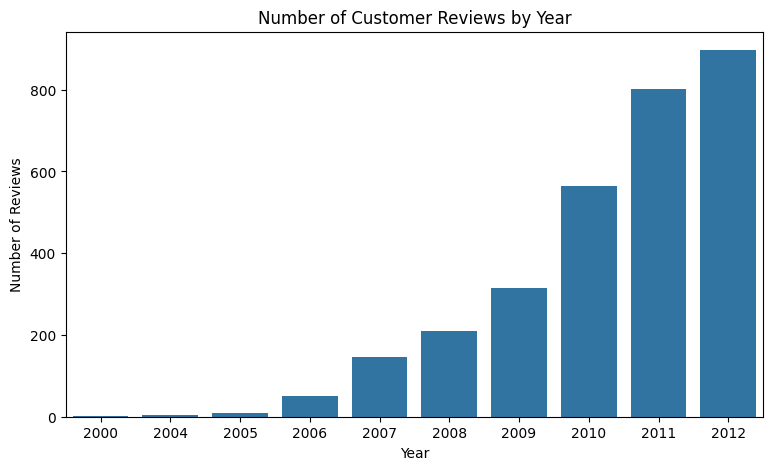

In [14]:
year_counts = df["Year"].value_counts().sort_index()

plt.figure(figsize=(9,5))

sns.barplot(
    x=year_counts.index,
    y=year_counts.values
)

plt.title("Number of Customer Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.show()

In [15]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Clean_Text"] = df["Text"].apply(clean_text)

print("Original Review:")
print(df["Text"].iloc[0])

print("\nCleaned Review:")
print(df["Clean_Text"].iloc[0])

Original Review:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

Cleaned Review:
i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador is finicky and she appreciates this product better than most


In [16]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["Processed_Text"] = df["Clean_Text"].apply(remove_stopwords)

print("Before Stopword Removal:")
print(df["Clean_Text"].iloc[0])

print("\nAfter Stopword Removal:")
print(df["Processed_Text"].iloc[0])

ModuleNotFoundError: No module named 'nltk'

In [17]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Dell-03\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Reviews_3000.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (3000, 10)


In [2]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["Processed_Text"] = df["Clean_Text"].apply(remove_stopwords)

print("Before Stopword Removal:")
print(df["Clean_Text"].iloc[0])

print("\nAfter Stopword Removal:")
print(df["Processed_Text"].iloc[0])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell-03\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dell-03\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Dell-03\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


KeyError: 'Clean_Text'

In [3]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Clean_Text"] = df["Text"].apply(clean_text)

print(df[["Text", "Clean_Text"]].head())

                                                Text  \
0  I have bought several of the Vitality canned d...   
1  Product arrived labeled as Jumbo Salted Peanut...   
2  This is a confection that has been around a fe...   
3  If you are looking for the secret ingredient i...   
4  Great taffy at a great price.  There was a wid...   

                                          Clean_Text  
0  i have bought several of the vitality canned d...  
1  product arrived labeled as jumbo salted peanut...  
2  this is a confection that has been around a fe...  
3  if you are looking for the secret ingredient i...  
4  great taffy at a great price there was a wide ...  


In [4]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["Processed_Text"] = df["Clean_Text"].apply(remove_stopwords)

print("Before Stopword Removal:")
print(df["Clean_Text"].iloc[0])

print("\nAfter Stopword Removal:")
print(df["Processed_Text"].iloc[0])

Before Stopword Removal:
i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador is finicky and she appreciates this product better than most

After Stopword Removal:
bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better


In [5]:
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell-03\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Dell-03\AppData\Roaming\nltk_data...


True

In [6]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

df["Final_Text"] = df["Processed_Text"].apply(lemmatize_text)

print("Before Lemmatization:")
print(df["Processed_Text"].iloc[0])

print("\nAfter Lemmatization:")
print(df["Final_Text"].iloc[0])

Before Lemmatization:
bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better

After Lemmatization:
bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better


In [7]:
print("Dataset Shape:", df.shape)

print("\nImportant Columns:")
print([
    "Text",
    "Score",
    "Sentiment",
    "Clean_Text",
    "Processed_Text",
    "Final_Text"
])

print("\nFinal Processed Text:")
print(df["Final_Text"].head())

Dataset Shape: (3000, 13)

Important Columns:
['Text', 'Score', 'Sentiment', 'Clean_Text', 'Processed_Text', 'Final_Text']

Final Processed Text:
0    bought several vitality canned dog food produc...
1    product arrived labeled jumbo salted peanutsth...
2    confection around century light pillowy citrus...
3    looking secret ingredient robitussin believe f...
4    great taffy great price wide assortment yummy ...
Name: Final_Text, dtype: object


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95
)

X_tfidf = tfidf.fit_transform(df["Final_Text"])

print("TF-IDF completed successfully!")
print("TF-IDF Matrix Shape:", X_tfidf.shape)

ModuleNotFoundError: No module named 'sklearn'

In [9]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Dell-03\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Reviews_3000.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (3000, 10)


In [3]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Clean_Text"] = df["Text"].apply(clean_text)

print("Clean_Text created successfully!")

Clean_Text created successfully!


In [4]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["Processed_Text"] = df["Clean_Text"].apply(remove_stopwords)

print("Processed_Text created successfully!")
print(df["Processed_Text"].head())

Processed_Text created successfully!
0    bought several vitality canned dog food produc...
1    product arrived labeled jumbo salted peanutsth...
2    confection around centuries light pillowy citr...
3    looking secret ingredient robitussin believe f...
4    great taffy great price wide assortment yummy ...
Name: Processed_Text, dtype: object


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell-03\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

df["Final_Text"] = df["Processed_Text"].apply(lemmatize_text)

print("Final_Text created successfully!")
print(df["Final_Text"].head())

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell-03\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Dell-03\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Final_Text created successfully!
0    bought several vitality canned dog food produc...
1    product arrived labeled jumbo salted peanutsth...
2    confection around century light pillowy citrus...
3    looking secret ingredient robitussin believe f...
4    great taffy great price wide assortment yummy ...
Name: Final_Text, dtype: object


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95
)

X_tfidf = tfidf.fit_transform(df["Final_Text"])

print("TF-IDF completed successfully!")
print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF completed successfully!
TF-IDF Matrix Shape: (3000, 5000)


In [8]:
from sklearn.decomposition import NMF

nmf = NMF(
    n_components=5,
    random_state=42,
    init="nndsvda"
)

W = nmf.fit_transform(X_tfidf)
H = nmf.components_

print("NMF completed successfully!")
print("W Matrix Shape:", W.shape)
print("H Matrix Shape:", H.shape)

NMF completed successfully!
W Matrix Shape: (3000, 5)
H Matrix Shape: (5, 5000)


In [9]:
feature_names = tfidf.get_feature_names_out()

for topic_idx, topic in enumerate(H):
    top_words = [
        feature_names[i]
        for i in topic.argsort()[-10:][::-1]
    ]
    
    print(f"Topic {topic_idx + 1}:")
    print(", ".join(top_words))
    print()

Topic 1:
food, product, br, good, one, love, like, dog, great, taste

Topic 2:
chip, bag, flavor, salt, potato, kettle, vinegar, great, like, calorie

Topic 3:
tea, green, drink, iced, water, like, taste, packet, flavor, br

Topic 4:
coffee, taste, cup, bold, like, strong, dark, one, flavor, smooth

Topic 5:
mix, waffle, pancake, make, best, easy, add, stonewall, family, recipe



In [10]:
df["Dominant_Topic"] = W.argmax(axis=1) + 1

print("Dominant Topic assigned successfully!")

print("\nTopic Distribution:")
print(df["Dominant_Topic"].value_counts().sort_index())

Dominant Topic assigned successfully!

Topic Distribution:
Dominant_Topic
1    1702
2     592
3     240
4     236
5     230
Name: count, dtype: int64


In [11]:
topic_counts = df["Dominant_Topic"].value_counts().sort_index()

topic_names = {
    1: "Food & Pet Products",
    2: "Chips & Snack Flavors",
    3: "Tea & Beverages",
    4: "Coffee Taste & Strength",
    5: "Pancake, Waffle & Baking Mixes"
}

topic_labels = [topic_names[i] for i in topic_counts.index]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=topic_labels,
    y=topic_counts.values
)

plt.title("Distribution of Customer Feedback Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

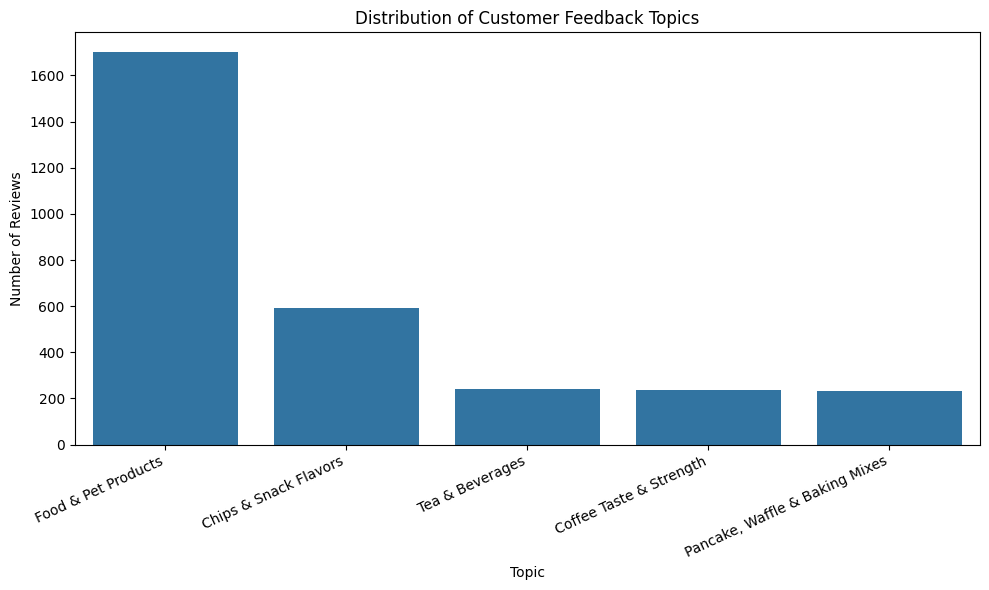

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

topic_counts = df["Dominant_Topic"].value_counts().sort_index()

topic_names = {
    1: "Food & Pet Products",
    2: "Chips & Snack Flavors",
    3: "Tea & Beverages",
    4: "Coffee Taste & Strength",
    5: "Pancake, Waffle & Baking Mixes"
}

topic_labels = [topic_names[i] for i in topic_counts.index]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=topic_labels,
    y=topic_counts.values
)

plt.title("Distribution of Customer Feedback Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

In [14]:
topic_evolution = pd.crosstab(
    df["Month"],
    df["Dominant_Topic"]
)

topic_evolution.columns = [
    f"Topic {col}" for col in topic_evolution.columns
]

print(topic_evolution.head())

KeyError: 'Month'

In [15]:
df["Date"] = pd.to_datetime(df["Time"], unit="s")
df["Month"] = df["Date"].dt.to_period("M").astype(str)

print("Month column created successfully!")
print(df[["Time", "Date", "Month"]].head())

Month column created successfully!
         Time       Date    Month
0  1303862400 2011-04-27  2011-04
1  1346976000 2012-09-07  2012-09
2  1219017600 2008-08-18  2008-08
3  1307923200 2011-06-13  2011-06
4  1350777600 2012-10-21  2012-10


In [16]:
topic_evolution = pd.crosstab(
    df["Month"],
    df["Dominant_Topic"]
)

topic_evolution.columns = [
    f"Topic {col}" for col in topic_evolution.columns
]

print("Topic Evolution Table:")
print(topic_evolution.head(10))

Topic Evolution Table:
         Topic 1  Topic 2  Topic 3  Topic 4  Topic 5
Month                                               
2000-06        2        0        0        0        0
2004-06        0        1        0        0        0
2004-08        2        0        0        0        0
2004-12        1        0        0        0        0
2005-01        1        0        0        0        0
2005-02        3        0        0        0        0
2005-09        3        0        0        0        0
2005-10        1        0        0        0        0
2005-12        1        0        0        0        0
2006-02        2        0        0        0        0


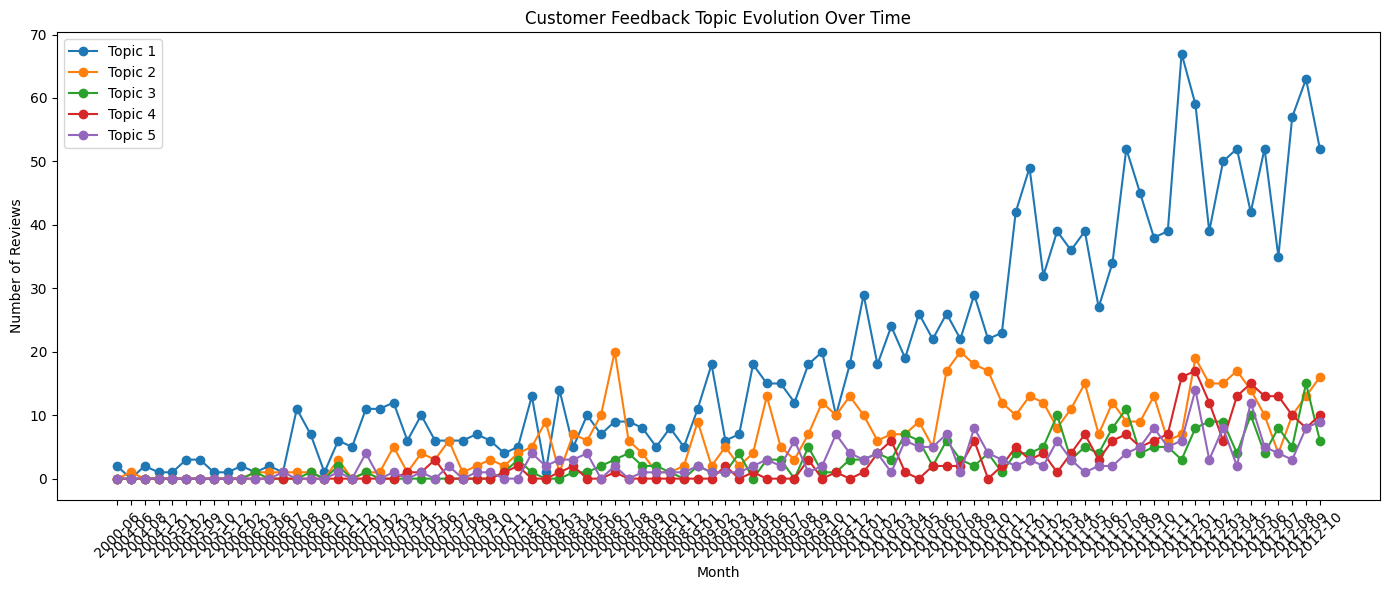

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for column in topic_evolution.columns:
    plt.plot(
        topic_evolution.index,
        topic_evolution[column],
        marker="o",
        label=column
    )

plt.title("Customer Feedback Topic Evolution Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
topic_keywords = []

for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[-10:][::-1]
    
    for rank, index in enumerate(top_indices, start=1):
        topic_keywords.append({
            "Topic": topic_idx + 1,
            "Topic_Name": topic_names[topic_idx + 1],
            "Rank": rank,
            "Keyword": feature_names[index],
            "Weight": topic[index]
        })

topic_keywords_df = pd.DataFrame(topic_keywords)

print("Topic Keywords Table:")
print(topic_keywords_df.head(20))

Topic Keywords Table:
    Topic             Topic_Name  Rank  Keyword    Weight
0       1    Food & Pet Products     1     food  0.677276
1       1    Food & Pet Products     2  product  0.673974
2       1    Food & Pet Products     3       br  0.660995
3       1    Food & Pet Products     4     good  0.589769
4       1    Food & Pet Products     5      one  0.516136
5       1    Food & Pet Products     6     love  0.514705
6       1    Food & Pet Products     7     like  0.513619
7       1    Food & Pet Products     8      dog  0.496800
8       1    Food & Pet Products     9    great  0.436859
9       1    Food & Pet Products    10    taste  0.370574
10      2  Chips & Snack Flavors     1     chip  1.810780
11      2  Chips & Snack Flavors     2      bag  0.554793
12      2  Chips & Snack Flavors     3   flavor  0.547307
13      2  Chips & Snack Flavors     4     salt  0.492718
14      2  Chips & Snack Flavors     5   potato  0.480751
15      2  Chips & Snack Flavors     6   kettle  0

In [19]:
from sklearn.model_selection import train_test_split

X = df["Final_Text"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

KeyError: 'Sentiment'

In [20]:
def get_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(get_sentiment)

print("Sentiment column created successfully!")
print(df["Sentiment"].value_counts())

Sentiment column created successfully!
Sentiment
Positive    2297
Negative     461
Neutral      242
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

X = df["Final_Text"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining sentiment distribution:")
print(y_train.value_counts())

Training samples: 2400
Testing samples: 600

Training sentiment distribution:
Sentiment
Positive    1838
Negative     369
Neutral      193
Name: count, dtype: int64


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF transformation completed!")
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

TF-IDF transformation completed!
Training TF-IDF shape: (2400, 4547)
Testing TF-IDF shape: (600, 4547)


In [23]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes model trained successfully!")
print("Predictions completed!")

Naive Bayes model trained successfully!
Predictions completed!


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average="weighted")
recall_nb = recall_score(y_test, y_pred_nb, average="weighted")
f1_nb = f1_score(y_test, y_pred_nb, average="weighted")

print("Naive Bayes Performance")
print("-----------------------")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1-Score :", round(f1_nb, 4))

Naive Bayes Performance
-----------------------
Accuracy : 0.7667
Precision: 0.7395
Recall   : 0.7667
F1-Score : 0.6671


c:\Users\Dell-03\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average="weighted")
recall_nb = recall_score(y_test, y_pred_nb, average="weighted")
f1_nb = f1_score(y_test, y_pred_nb, average="weighted")

print("Naive Bayes Performance")
print("-----------------------")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1-Score :", round(f1_nb, 4))

Naive Bayes Performance
-----------------------
Accuracy : 0.7667
Precision: 0.7395
Recall   : 0.7667
F1-Score : 0.6671


c:\Users\Dell-03\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


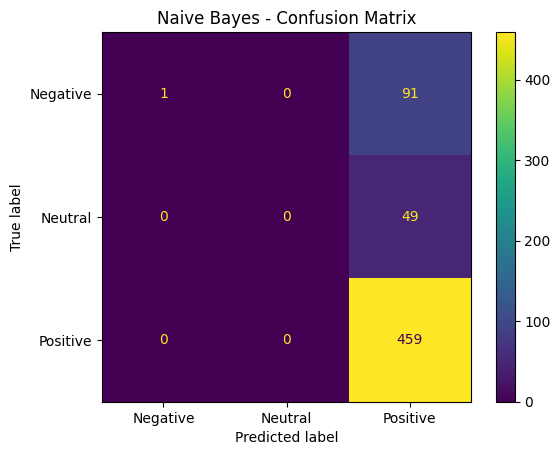

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression model trained successfully!")
print("Predictions completed!")

Logistic Regression model trained successfully!
Predictions completed!


In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average="weighted")
recall_lr = recall_score(y_test, y_pred_lr, average="weighted")
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Performance")
print("-------------------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1-Score :", round(f1_lr, 4))

Logistic Regression Performance
-------------------------------
Accuracy : 0.8017
Precision: 0.7352
Recall   : 0.8017
F1-Score : 0.7386


c:\Users\Dell-03\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average="weighted")
recall_lr = recall_score(y_test, y_pred_lr, average="weighted")
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Performance")
print("-------------------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1-Score :", round(f1_lr, 4))

Logistic Regression Performance
-------------------------------
Accuracy : 0.8017
Precision: 0.7352
Recall   : 0.8017
F1-Score : 0.7386


c:\Users\Dell-03\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


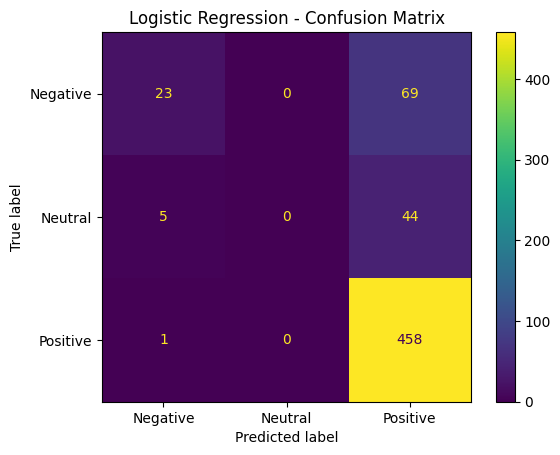

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [32]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM model trained successfully!")
print("Predictions completed!")

SVM model trained successfully!
Predictions completed!


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average="weighted")
recall_svm = recall_score(y_test, y_pred_svm, average="weighted")
f1_svm = f1_score(y_test, y_pred_svm, average="weighted")

print("SVM Performance")
print("----------------")
print("Accuracy :", round(accuracy_svm, 4))
print("Precision:", round(precision_svm, 4))
print("Recall   :", round(recall_svm, 4))
print("F1-Score :", round(f1_svm, 4))

SVM Performance
----------------
Accuracy : 0.8433
Precision: 0.8252
Recall   : 0.8433
F1-Score : 0.8161


In [35]:
model_comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_lr,
        accuracy_svm
    ],
    "Precision": [
        precision_nb,
        precision_lr,
        precision_svm
    ],
    "Recall": [
        recall_nb,
        recall_lr,
        recall_svm
    ],
    "F1-Score": [
        f1_nb,
        f1_lr,
        f1_svm
    ]
})

model_comparison = model_comparison.round(4)

print("Model Performance Comparison:")
display(model_comparison)

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.7667,0.7395,0.7667,0.6671
1,Logistic Regression,0.8017,0.7352,0.8017,0.7386
2,SVM,0.8433,0.8252,0.8433,0.8161


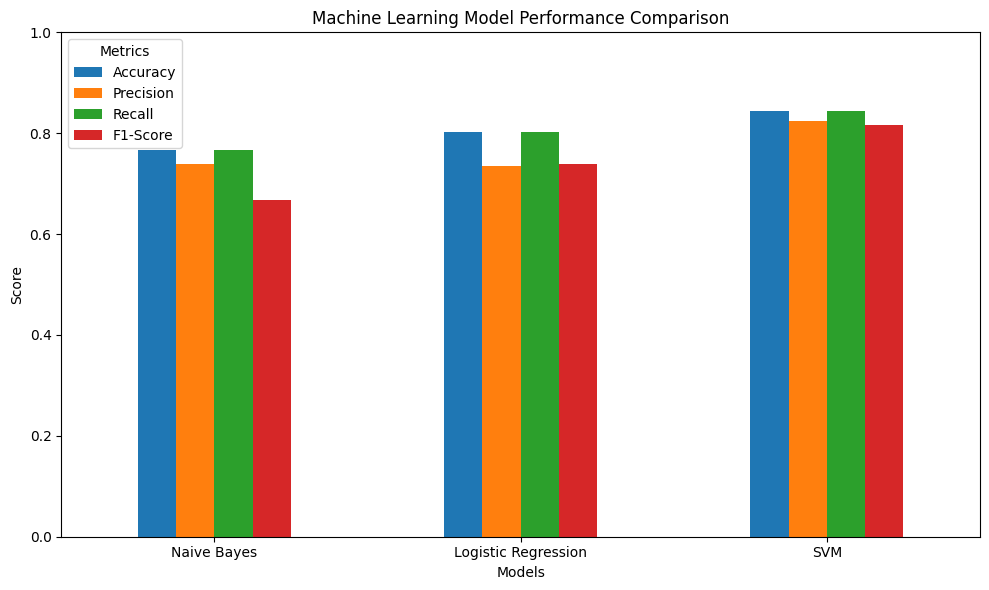

In [36]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

model_comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(df["Final_Text"].astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Customer Feedback Word Cloud")
plt.show()

ModuleNotFoundError: No module named 'wordcloud'

In [38]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Dell-03\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [39]:
from wordcloud import WordCloud

print("WordCloud installed successfully!")

WordCloud installed successfully!


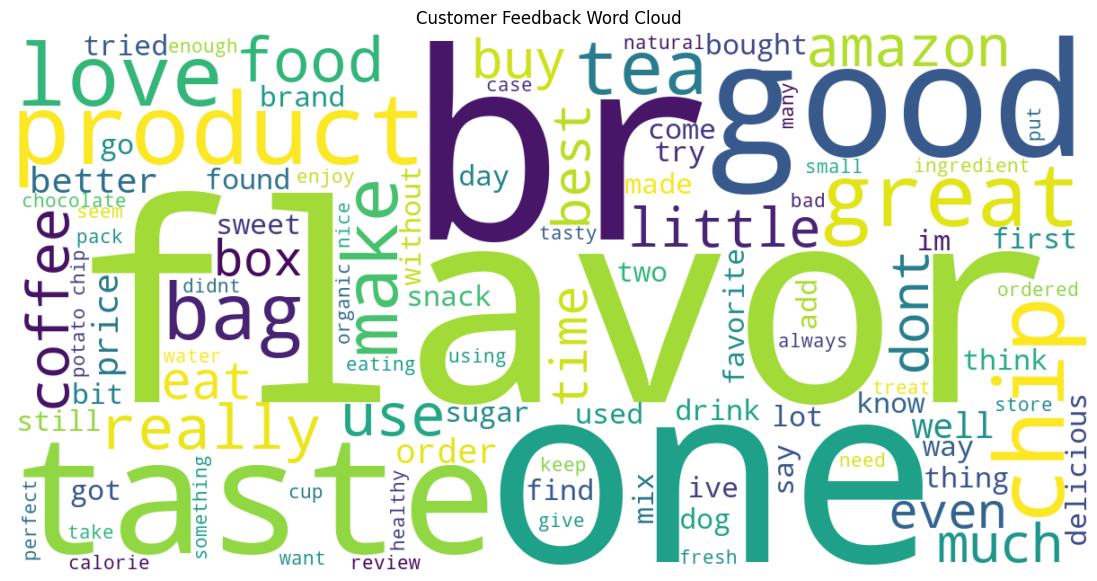

In [40]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(df["Final_Text"].astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Customer Feedback Word Cloud")
plt.show()

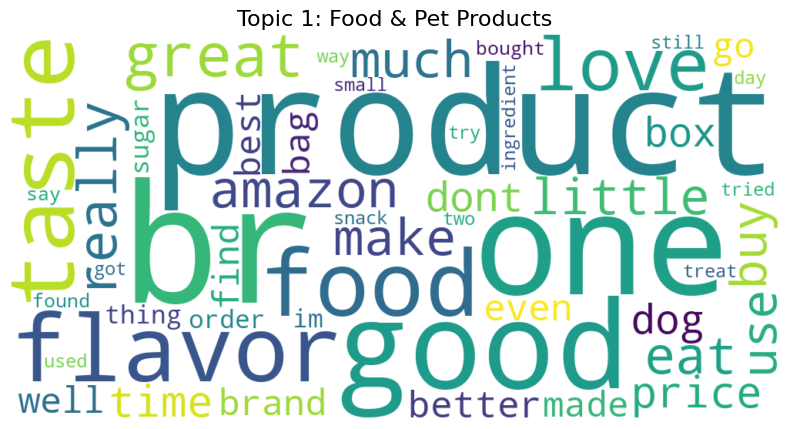

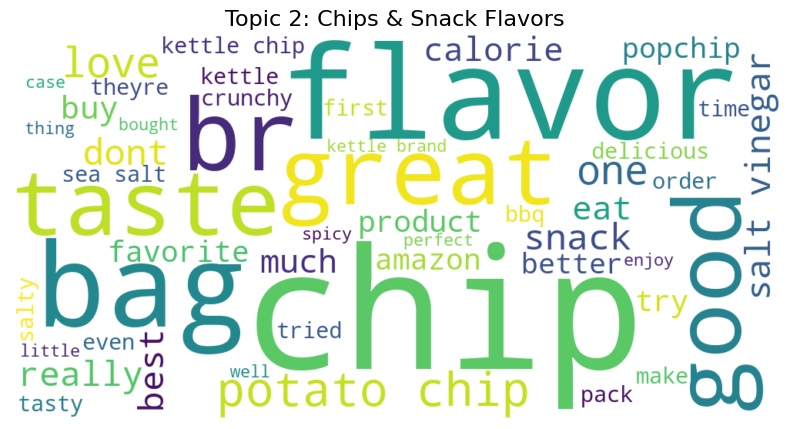

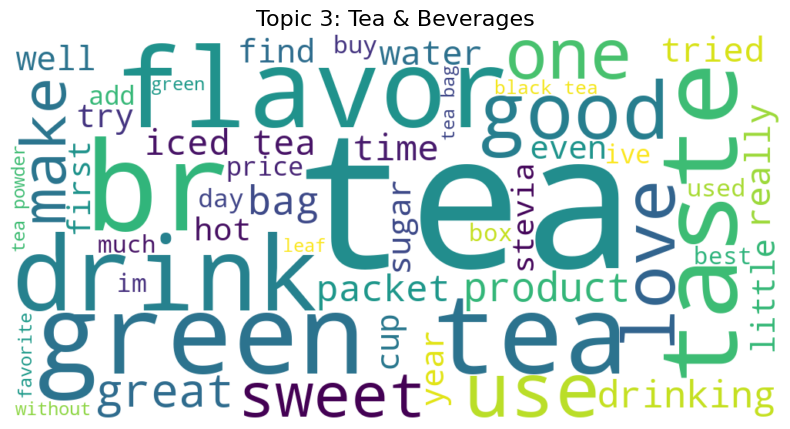

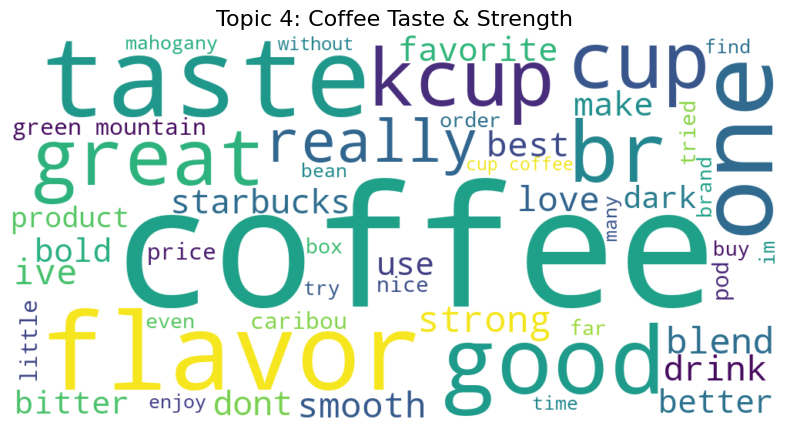

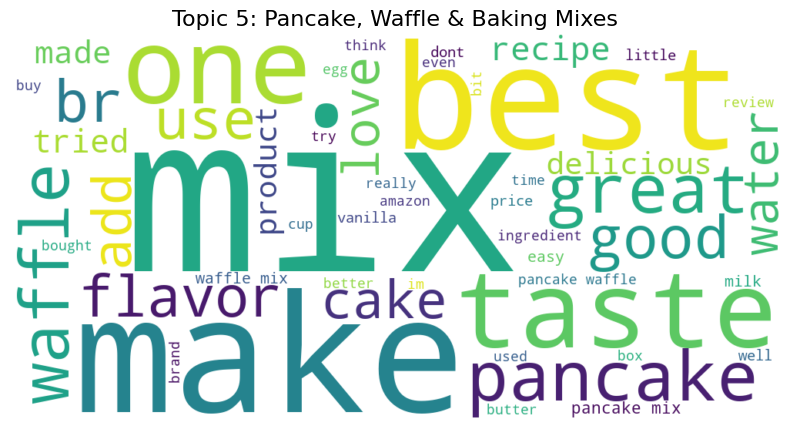

In [41]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for topic_num in sorted(df["Dominant_Topic"].unique()):
    
    topic_text = " ".join(
        df[df["Dominant_Topic"] == topic_num]["Final_Text"].astype(str)
    )
    
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=50
    ).generate(topic_text)
    
    plt.figure(figsize=(12, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(
        f"Topic {topic_num}: {topic_names[topic_num]}",
        fontsize=16
    )
    plt.show()

In [42]:
# Save processed dataset

output_columns = [
    "Id",
    "ProductId",
    "Score",
    "Summary",
    "Text",
    "Date",
    "Year",
    "Month",
    "Sentiment",
    "Review_Length",
    "Final_Text",
    "Dominant_Topic"
]

processed_df = df[output_columns].copy()

processed_df.to_csv(
    "../Output/processed_feedback.csv",
    index=False
)

print("Processed dataset saved successfully!")
print("File: Output/processed_feedback.csv")
print("Shape:", processed_df.shape)

KeyError: "['Year', 'Review_Length'] not in index"

In [43]:
# Recreate missing columns

df["Date"] = pd.to_datetime(df["Time"], unit="s")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.to_period("M").astype(str)

df["Review_Length"] = df["Text"].astype(str).apply(len)

print("Required columns recreated successfully!")
print(df[["Date", "Year", "Month", "Review_Length"]].head())

Required columns recreated successfully!
        Date  Year    Month  Review_Length
0 2011-04-27  2011  2011-04            263
1 2012-09-07  2012  2012-09            190
2 2008-08-18  2008  2008-08            509
3 2011-06-13  2011  2011-06            219
4 2012-10-21  2012  2012-10            140


In [44]:
output_columns = [
    "Id",
    "ProductId",
    "Score",
    "Summary",
    "Text",
    "Date",
    "Year",
    "Month",
    "Sentiment",
    "Review_Length",
    "Final_Text",
    "Dominant_Topic"
]

processed_df = df[output_columns].copy()

processed_df.to_csv(
    "../Output/processed_feedback.csv",
    index=False
)

print("Processed dataset saved successfully!")
print("Shape:", processed_df.shape)

Processed dataset saved successfully!
Shape: (3000, 12)


In [46]:
topic_keywords_df.to_csv(
    "../Output/topic_keywords.csv",
    index=False
)

print("Topic keywords saved successfully!")
print("File: Output/topic_keywords.csv")

Topic keywords saved successfully!
File: Output/topic_keywords.csv


In [48]:
topic_evolution.to_csv(
    "../Output/topic_evolution.csv"
)

print("Topic evolution saved successfully!")
print("File: Output/topic_evolution.csv")

Topic evolution saved successfully!
File: Output/topic_evolution.csv


In [49]:
model_comparison.to_csv(
    "../Output/model_performance.csv",
    index=False
)

print("Model performance saved successfully!")
print("File: Output/model_performance.csv")

Model performance saved successfully!
File: Output/model_performance.csv


In [50]:
wordcloud.to_file("../Output/customer_feedback_wordcloud.png")

In [51]:
wordcloud.to_file("../Output/customer_feedback_wordcloud.png")

print("Word Cloud saved successfully!")

Word Cloud saved successfully!
